# Predicting Rainfall at Parafield Using Bureau of Meteorology Weather Observation Data

**Author:** Alexander Montague  
**Completed:** 16 June 2026  
**Data period:** 1 May 2025 to 2 June 2026  
**Data source:** Bureau of Meteorology daily weather observations for Parafield Airport, South Australia

## Project Objective

This project investigates whether daily weather observations from Parafield Airport can be used to predict future rainfall, specifically whether rain is recorded during the next complete Bureau of Meteorology rainfall observation period. The project includes data cleaning, exploratory analysis, feature engineering, time-aware target construction, model comparison, and interpretation of important predictors.

## 1. Import Packages

Import the core data science, visualisation, preprocessing, modelling, and evaluation packages used throughout the project.

In [ ]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.base import clone

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    make_scorer,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Display
from IPython.display import Markdown

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Load and Inspect Data

Load the combined Bureau of Meteorology weather observation dataset and inspect its structure, missing values, and first few records.

In [ ]:
# Load dataset
df = pd.read_csv("combined_parafield_may_2025_to_june_2026.csv")

# Preview first few rows
display(Markdown("### First five rows"))
display(df.head())

# Inspect column names, data types, and non-null counts
display(Markdown("### Dataset information"))
df.info()

# Check dataset size
display(Markdown("### Dataset shape"))
display(df.shape)

# Summary statistics for numeric columns
print("\nSummary statistics:")
display(df.describe())

# Inspect columns with the most missing values
display(Markdown("### Top 5 columns by missing values"))
display(df.isna().sum().sort_values(ascending=False).head(5))

### First five rows

,Date,Minimum temperature (°C),Maximum temperature (°C),Rainfall (mm),Evaporation (mm),Sunshine (hours),Direction of maximum wind gust,Speed of maximum wind gust (km/h),Time of maximum wind gust,9am Temperature (°C),9am relative humidity (%),9am cloud amount (oktas),9am wind direction,9am wind speed (km/h),9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind direction,3pm wind speed (km/h),3pm MSL pressure (hPa)
0,1/05/2025,4.600,21.300,0.000,NaN,NaN,NE,30.000,16:03,14.100,70,NaN,SE,9,1033.200,20.900,34.000,NaN,ESE,9.000,1029.900
1,2/05/2025,5.100,24.300,0.000,NaN,NaN,N,31.000,13:45,16.800,44,NaN,NE,17,1032.300,21.700,35.000,NaN,WSW,13.000,1028.300
2,3/05/2025,11.600,26.400,0.000,NaN,NaN,N,43.000,11:12,19.000,30,NaN,NNE,24,1030.300,26.200,19.000,NaN,N,20.000,1024.900
3,4/05/2025,13.300,28.300,0.000,NaN,NaN,N,57.000,11:20,21.900,38,NaN,NNE,24,1026.000,26.800,25.000,NaN,NNW,26.000,1021.400
4,5/05/2025,18.200,28.400,0.000,NaN,NaN,NW,50.000,12:12,22.700,35,NaN,N,26,1021.500,27.500,25.000,NaN,NW,28.000,1018.200


### Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               398 non-null    object 
 1   Minimum temperature (°C)           398 non-null    float64
 2   Maximum temperature (°C)           396 non-null    float64
 3   Rainfall (mm)                      398 non-null    float64
 4   Evaporation (mm)                   0 non-null      float64
 5   Sunshine (hours)                   0 non-null      float64
 6   Direction of maximum wind gust     395 non-null    object 
 7   Speed of maximum wind gust (km/h)  395 non-null    float64
 8   Time of maximum wind gust          395 non-null    object 
 9   9am Temperature (°C)               398 non-null    float64
 10  9am relative humidity (%)          398 non-null    int64  
 11  9am cloud amount (oktas)           243 non-null    float64

### Dataset shape

(398, 21)


Summary statistics:


,Minimum temperature (°C),Maximum temperature (°C),Rainfall (mm),Evaporation (mm),Sunshine (hours),Speed of maximum wind gust (km/h),9am Temperature (°C),9am relative humidity (%),9am cloud amount (oktas),9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind speed (km/h),3pm MSL pressure (hPa)
count,398.000,396.000,398.000,0.000,0.000,395.000,398.000,398.000,243.000,398.000,397.000,397.000,220.000,397.000,397.000
mean,11.033,23.412,1.314,NaN,NaN,39.790,17.118,62.962,6.605,1018.056,21.781,47.065,6.191,19.834,1016.032
std,5.092,6.848,3.411,NaN,NaN,12.109,5.518,20.138,2.232,7.435,6.674,18.734,2.427,7.465,7.011
min,-0.700,11.800,0.000,NaN,NaN,15.000,6.100,11.000,1.000,997.500,9.900,7.000,1.000,2.000,994.400
25%,7.500,18.100,0.000,NaN,NaN,31.000,13.325,49.000,6.000,1012.925,16.800,33.000,4.000,15.000,1011.200
50%,10.950,21.950,0.000,NaN,NaN,39.000,16.000,64.000,8.000,1017.900,20.400,47.000,7.500,19.000,1015.800
75%,14.000,27.900,0.600,NaN,NaN,48.000,20.200,78.000,8.000,1023.050,25.900,59.000,8.000,24.000,1020.600
max,29.500,45.500,25.000,NaN,NaN,83.000,40.400,98.000,8.000,1034.200,44.300,93.000,8.000,43.000,1031.800


### Top 5 columns by missing values

Evaporation (mm)                     398
Sunshine (hours)                     398
3pm cloud amount (oktas)             178
9am cloud amount (oktas)             155
Speed of maximum wind gust (km/h)      3
dtype: int64

After the initial inspection, the dataset contains 398 rows and 21 variables. Most variables have complete or near-complete records, although several columns contain substantial missing data.

`Evaporation (mm)` and `Sunshine (hours)` both have 0 non-null values, meaning they do not provide usable information for this dataset and can be removed during data cleaning.

The cloud amount variables also contain many missing values, with `3pm cloud amount (oktas)` missing 178 values and `9am cloud amount (oktas)` missing 155 values. These columns may still contain useful information, so they will need further consideration before deciding whether to keep, remove, or impute them.

## 3. Data Cleaning and Feature Preparation

Prepare the dataset for analysis by cleaning column names, checking missing values, converting date fields, and constructing time-aware rainfall targets.

In [ ]:
# Create a working copy of the dataset
data = df.copy()

# Remove extra whitespace from column names
data.columns = data.columns.str.strip()

# Rename columns into a consistent snake_case format
column_name_map = {
    "Date": "date",
    "Minimum temperature (°C)": "min_temp",
    "Maximum temperature (°C)": "max_temp",
    "Rainfall (mm)": "rainfall",
    "Evaporation (mm)": "evaporation",
    "Sunshine (hours)": "sunshine",
    "Direction of maximum wind gust": "max_wind_gust_direction",
    "Speed of maximum wind gust (km/h)": "max_wind_gust_speed",
    "Time of maximum wind gust": "max_wind_gust_time",
    "9am Temperature (°C)": "temp_9am",
    "9am relative humidity (%)": "humidity_9am",
    "9am cloud amount (oktas)": "cloud_amount_9am",
    "9am wind direction": "wind_direction_9am",
    "9am wind speed (km/h)": "wind_speed_9am",
    "9am MSL pressure (hPa)": "pressure_9am",
    "3pm Temperature (°C)": "temp_3pm",
    "3pm relative humidity (%)": "humidity_3pm",
    "3pm cloud amount (oktas)": "cloud_amount_3pm",
    "3pm wind direction": "wind_direction_3pm",
    "3pm wind speed (km/h)": "wind_speed_3pm",
    "3pm MSL pressure (hPa)": "pressure_3pm",
}
data = data.rename(columns=column_name_map)

# Drop columns with no observed values
columns_to_drop = ["evaporation", "sunshine"]
data = data.drop(columns=columns_to_drop)

# Convert Date to datetime, sort chronologically, and use it as the index
data["date"] = pd.to_datetime(data["date"], dayfirst=True, errors="coerce")
data = data.dropna(subset=["date"])
data = data.sort_values("date").set_index("date")

# Preview first five rows of the cleaned dataset
display(Markdown("### First five rows of cleaned dataset"))
display(data.head())

# Check cleaned dataset size
display(Markdown("### Cleaned dataset shape"))
display(data.shape)

# Inspect columns with the most missing values after initial cleaning
display(Markdown("### Top 5 columns by missing values after initial cleaning"))
display(data.isna().sum().sort_values(ascending=False).head(5))

### First five rows of cleaned dataset

,min_temp,max_temp,rainfall,max_wind_gust_direction,max_wind_gust_speed,max_wind_gust_time,temp_9am,humidity_9am,cloud_amount_9am,wind_direction_9am,wind_speed_9am,pressure_9am,temp_3pm,humidity_3pm,cloud_amount_3pm,wind_direction_3pm,wind_speed_3pm,pressure_3pm
date,,,,,,,,,,,,,,,,,,
2025-05-01,4.600,21.300,0.000,NE,30.000,16:03,14.100,70,NaN,SE,9,1033.200,20.900,34.000,NaN,ESE,9.000,1029.900
2025-05-02,5.100,24.300,0.000,N,31.000,13:45,16.800,44,NaN,NE,17,1032.300,21.700,35.000,NaN,WSW,13.000,1028.300
2025-05-03,11.600,26.400,0.000,N,43.000,11:12,19.000,30,NaN,NNE,24,1030.300,26.200,19.000,NaN,N,20.000,1024.900
2025-05-04,13.300,28.300,0.000,N,57.000,11:20,21.900,38,NaN,NNE,24,1026.000,26.800,25.000,NaN,NNW,26.000,1021.400
2025-05-05,18.200,28.400,0.000,NW,50.000,12:12,22.700,35,NaN,N,26,1021.500,27.500,25.000,NaN,NW,28.000,1018.200


### Cleaned dataset shape

(398, 18)

### Top 5 columns by missing values after initial cleaning

cloud_amount_3pm           178
cloud_amount_9am           155
max_wind_gust_speed          3
max_wind_gust_direction      3
max_wind_gust_time           3
dtype: int64

The cloud amount variables contain substantially more missing values than any other feature in the dataset, with approximately 45% of observations missing for `cloud_amount_3pm` and 39% missing for `cloud_amount_9am`.

Cloud amount is intuitively relevant to rainfall prediction, as rainfall cannot occur without cloud formation. However, the dataset documentation does not indicate that missing cloud observations correspond to clear sky conditions, so the missing values cannot simply be interpreted as zero cloud cover.

Several approaches are possible. One option is to exclude the cloud amount variables entirely and build a model using the remaining weather observations. Another option is to retain the cloud amount variables and apply an imputation strategy during model preparation.

Given the relatively small dataset size (398 observations), removing all rows with missing cloud observations would result in a substantial loss of data. For this reason, the cloud amount variables will be investigated further during the EDA and modelling stage before a final decision is made.

In [ ]:
# Create date-based features
data["month"] = data.index.month
data["day_of_year"] = data.index.dayofyear

# Assign Australian seasons based on calendar month
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

data["season"] = data["month"].apply(get_season)

# Inspect season distribution
display(Markdown("### Season distribution"))
display(data["season"].value_counts())

### Season distribution

season
Autumn    123
Winter     94
Spring     91
Summer     90
Name: count, dtype: int64

In [ ]:
# Replace "Calm" wind speed values with a low numeric approximation
data["wind_speed_9am"] = data["wind_speed_9am"].replace("Calm", 1)

# Convert wind speed column to numeric
data["wind_speed_9am"] = pd.to_numeric(data["wind_speed_9am"], errors="coerce")

# Check updated data type and values
display(Markdown("### 9am wind speed after cleaning"))
display(data["wind_speed_9am"].describe())

### 9am wind speed after cleaning

count   398.000
mean     14.274
std       8.620
min       1.000
25%       7.000
50%      13.000
75%      20.000
max      46.000
Name: wind_speed_9am, dtype: float64

The `wind_speed_9am` column contained some `"Calm"` values. Since calm wind indicates a very low wind speed below 2 km/h, these values were replaced with `1` as a midpoint approximation before converting the column to numeric.

In [ ]:
# Construct binary target for the next complete BoM rainfall observation period
forecast_horizon = 2

# Shift by two rows so the target period begins after the current day's observations
rainfall_future = data["rainfall"].shift(-forecast_horizon)

# Create target: 1 = rain tomorrow, 0 = no rain tomorrow
data["rain_tomorrow"] = np.where(
    rainfall_future.notna(),
    rainfall_future.gt(0).astype(int),
    np.nan,
)
data["rain_tomorrow"] = data["rain_tomorrow"].astype("Int64")

# Remove rows where the target cannot be constructed
data = data.dropna(subset=["rain_tomorrow"])

# Check target distribution
display(Markdown("### Rain tomorrow target distribution"))
display(data["rain_tomorrow"].value_counts().rename(index={0: "No rain tomorrow", 1: "Rain tomorrow"}))

display(Markdown("### Dataset shape after target construction"))
display(data.shape)

### Rain tomorrow target distribution

rain_tomorrow
No rain tomorrow    257
Rain tomorrow       139
Name: count, dtype: Int64

### Dataset shape after target construction

(396, 22)

The dataset has been cleaned and standardised by renaming variables, removing columns with no observed values, converting the date column to a datetime format, and creating the target variable `rain_tomorrow`.

Because Bureau of Meteorology daily rainfall is recorded at 9am for the preceding 24 hours, the target is shifted by two rows. This means the target rainfall period begins after all weather observations from the current day have been recorded, avoiding overlap between the predictor period and the rainfall outcome period.

The target therefore represents whether rain is recorded during the next complete BoM rainfall observation period rather than an exact midnight-to-midnight calendar day. With the target defined, the next step is to explore the weather variables in more detail to identify patterns, relationships, and potentially informative predictors for rainfall forecasting.

## 4. Exploratory Data Analysis

The purpose of this section is to explore the structure of the dataset and identify potential relationships between the predictor variables and the target variable, `rain_tomorrow`.

The analysis will focus on:
- Understanding the distribution of weather variables.
- Investigating rainfall patterns over time.
- Examining relationships between weather conditions and rainfall occurrence.
- Identifying potentially important predictors for the modelling stage.
- Detecting any unusual observations or data quality issues that may influence model performance.

Insights from this analysis will be used to guide feature selection and modelling decisions in the predictive modelling section.

### 4.1 Rainfall Patterns and Seasonality

Before investigating individual predictor variables, it is useful to understand how rainfall is distributed throughout the observation period. Examining rainfall patterns over time can reveal seasonal effects, prolonged dry periods, and clusters of rainfall events that may influence the modelling process.

The following plots explore the temporal behaviour of rainfall and provide an initial understanding of the target phenomenon being predicted.

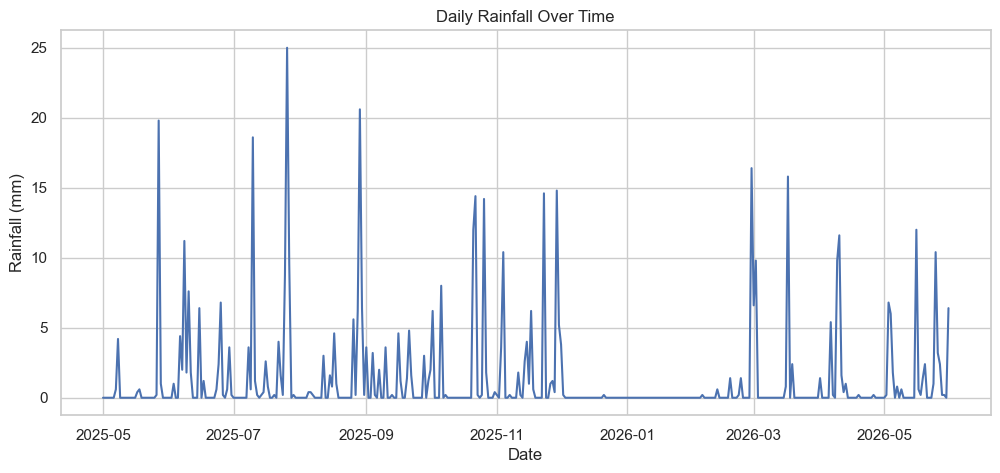

In [ ]:
# Plot of daily rainfall over time
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["rainfall"])
plt.title("Daily Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()

The rainfall time series shows that precipitation is highly intermittent, with many days recording little or no rainfall and occasional periods of more substantial rainfall.

A noticeable seasonal pattern is visible, with rainfall activity declining substantially during the summer months (December to February). In contrast, rainfall events appear more frequent and larger in magnitude during the cooler months of the year.

The series also demonstrates that rainfall tends to occur in clusters rather than being evenly distributed through time. This suggests that weather conditions on previous days may contain useful information for predicting rainfall on the following day.

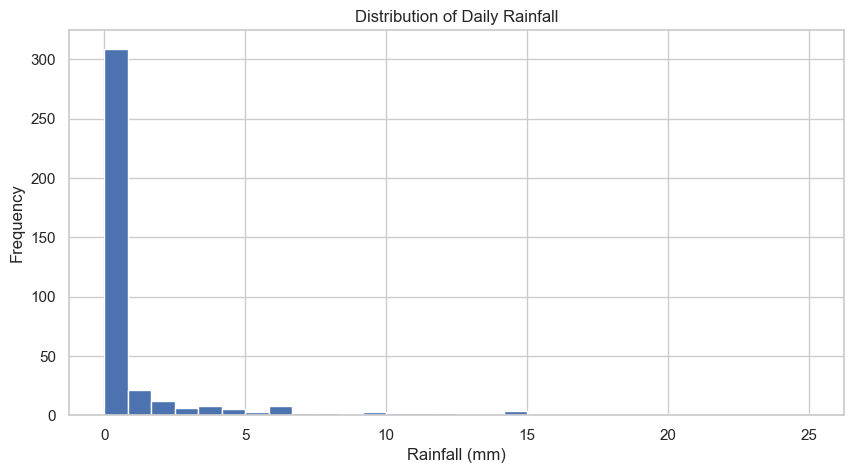

Percentage of dry days: 65.4%


In [ ]:
# Histogram of daily rainfall
plt.figure(figsize=(10, 5))
plt.hist(data["rainfall"], bins=30)
plt.title("Distribution of Daily Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

# Percentage of dry days 
dry_day_pct = (data["rainfall"] == 0).mean() * 100
print(f"Percentage of dry days: {dry_day_pct:.1f}%")

The histogram confirms that daily rainfall is highly right-skewed, with 65.4% of days recording no rainfall. Most rainfall observations are either zero or very small, while larger rainfall events are rare.

For this project, the target variable treats any positive rainfall amount as a rainfall day. This means that very light rainfall is classified the same way as heavier rainfall. While this loses information about rainfall intensity, it is appropriate for the main classification task, which focuses on predicting whether rain occurs rather than how much rain falls.

Predicting the actual rainfall amount would be an interesting extension of this project, but it would require a different modelling approach, such as regression, and may be more difficult due to the large number of zero-rainfall days and the small number of larger rainfall events.

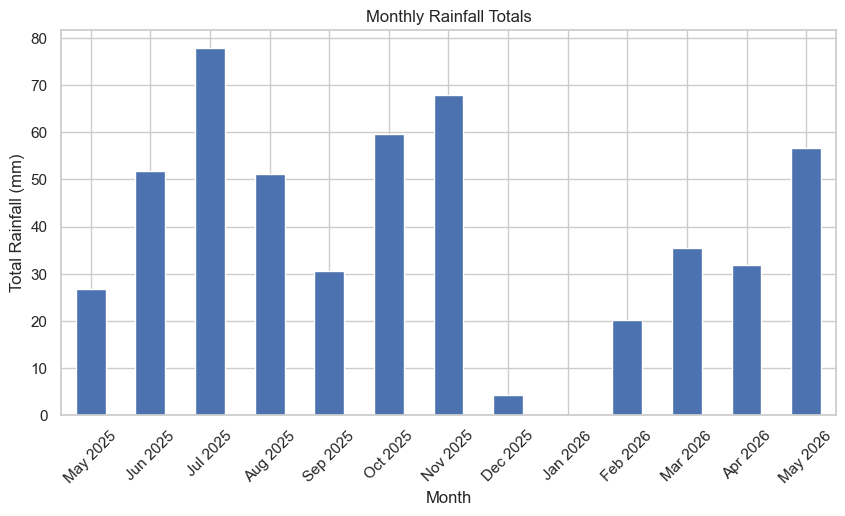

In [ ]:
# Calculate monthly rainfall totals
monthly_rainfall = data["rainfall"].resample("ME").sum()
monthly_rainfall.index = monthly_rainfall.index.strftime("%b %Y")

# Plot monthly rainfall totals
plt.figure(figsize=(10, 5))
monthly_rainfall.plot(kind="bar")
plt.title("Monthly Rainfall Totals")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

The monthly rainfall totals highlight a noticeable seasonal pattern within the observation period. Rainfall was highest during July 2025, with additional peaks occurring in October and November 2025. In contrast, December 2025 and January 2026 recorded very little rainfall, indicating a particularly dry summer period.

The increase in rainfall during the cooler months and the sharp reduction during summer suggest that seasonal effects may play an important role in rainfall occurrence. This indicates that month- or season-based features could potentially provide useful information for the predictive modelling stage.

The June 2026 total should be interpreted with caution, as the dataset only contains observations from the first few days of the month.

### 4.2 Relationships Between Numeric Variables and Rain Tomorrow
Having explored the seasonal behaviour of rainfall, the next step is to examine how the numeric weather variables differ between days that are followed by rainfall and days that are not.

The boxplots below compare the distribution of the main numeric predictor variables across the two Rain Tomorrow outcomes. Variables that show greater separation between the groups may contain useful information for predicting rainfall occurrence, while variables with substantial overlap may provide weaker predictive power when considered individually.

The cloud amount variables are initially excluded from these main boxplots because they contain a large proportion of missing values compared with the other numeric predictors. Rather than allowing these variables to dominate or distort the initial numeric EDA, they are examined separately after the main numeric predictors.

It is important to note that a variable showing considerable overlap is not necessarily uninformative. Predictive models can often exploit combinations of variables and interactions between weather conditions that are not immediately apparent from individual plots.

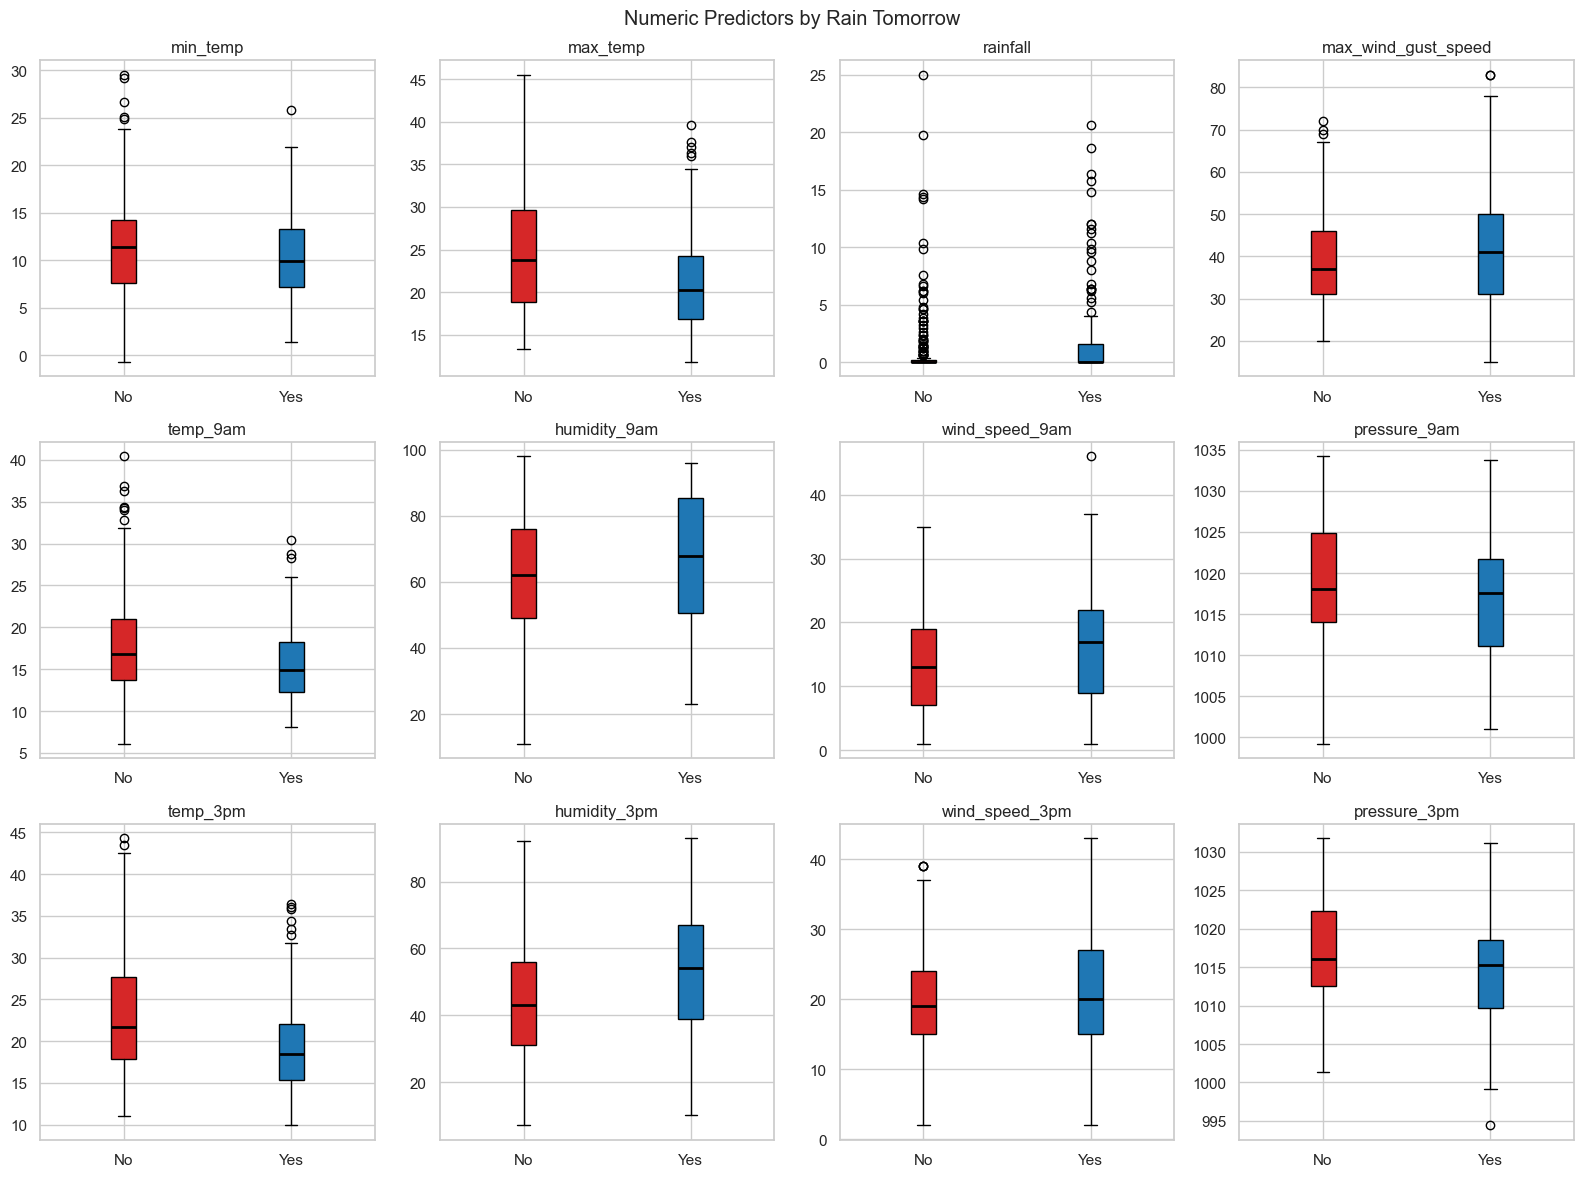

In [ ]:
# Create boxplots for numeric predictors by rain tomorrow outcome

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

numeric_predictors = [
    "min_temp",
    "max_temp",
    "rainfall",
    "max_wind_gust_speed",
    "temp_9am",
    "humidity_9am",
    "wind_speed_9am",
    "pressure_9am",
    "temp_3pm",
    "humidity_3pm",
    "wind_speed_3pm",
    "pressure_3pm"
]

for ax, col in zip(axes, numeric_predictors):

    no_rain = data.loc[data["rain_tomorrow"] == 0, col].dropna()
    rain = data.loc[data["rain_tomorrow"] == 1, col].dropna()

    bp = ax.boxplot(
        [no_rain, rain],
        tick_labels=["No", "Yes"],
        patch_artist=True
    )

    bp["boxes"][0].set_facecolor("#d62728")
    bp["boxes"][1].set_facecolor("#1f77b4")

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    ax.set_title(col)

plt.suptitle("Numeric Predictors by Rain Tomorrow")
plt.tight_layout()
plt.show()

Overall, the numeric predictors show meaningful differences between the two target classes, suggesting that several variables may be useful for predicting whether rainfall occurs the following day.

The clearest separation appears in the humidity variables, particularly `humidity_3pm`, where days followed by rain tend to have substantially higher values. Temperature and pressure variables also show noticeable separation, with rain-following days generally having lower daytime temperatures and lower atmospheric pressure.

Wind-related variables show a weaker but still visible pattern, with higher wind speeds and maximum wind gust speeds tending to occur before rainfall days. The `rainfall` variable also shows a larger upper tail for days followed by rain, suggesting that current-day rainfall may contain useful information about next-day rainfall.

Some variables, such as `min_temp` and `wind_speed_9am`, show greater overlap between the two classes and may be weaker individual predictors. However, even variables with overlap may still contribute useful information when combined with other predictors in a classification model.

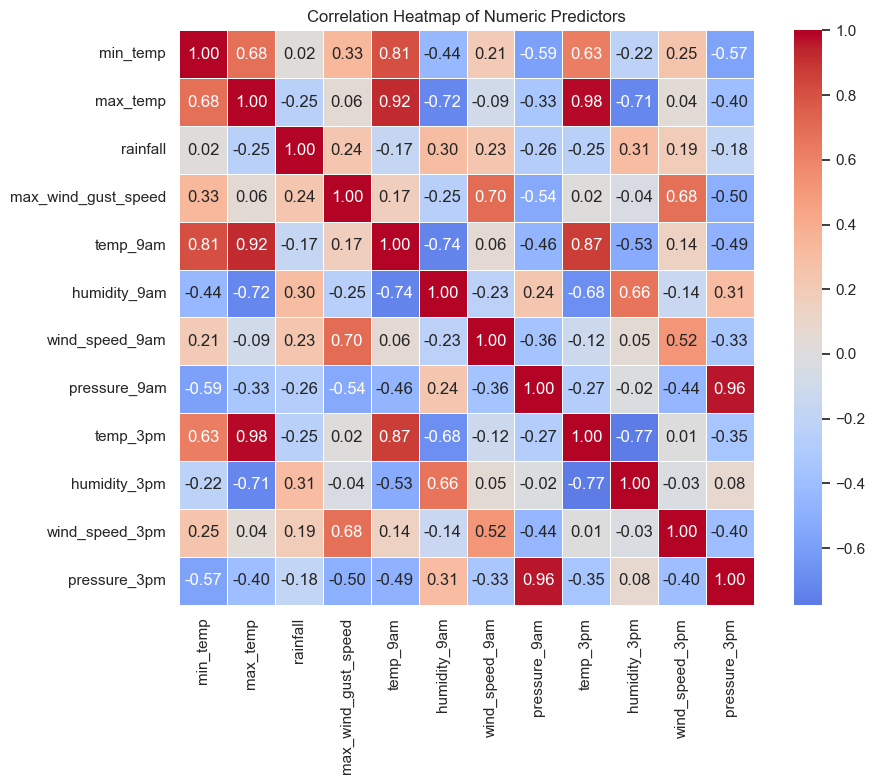

In [ ]:
# Calculate correlation matrix for numeric predictors
corr_matrix = data[numeric_predictors].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Predictors")
plt.tight_layout()
plt.show()

The correlation heatmap shows several strong relationships between the numeric predictors. The strongest correlation is between `pressure_9am` and `pressure_3pm`, indicating that the two pressure measurements contain very similar information. The temperature variables are also strongly correlated, particularly `max_temp` with `temp_3pm`, and `min_temp` with `temp_9am`.

Humidity is negatively correlated with the temperature variables, suggesting that hotter days in this dataset generally correspond to lower relative humidity. The humidity variables are also positively correlated with rainfall, while pressure and maximum temperature show negative correlations with rainfall. Maximum wind gust speed is moderately positively correlated with rainfall, which supports the patterns observed in the earlier boxplots.

Overall, the heatmap suggests that several predictors contain overlapping information. This may be relevant for models sensitive to multicollinearity, such as logistic regression, but less problematic for tree-based models. Despite this, the variables will initially be retained so that the modelling stage can assess their combined predictive value.

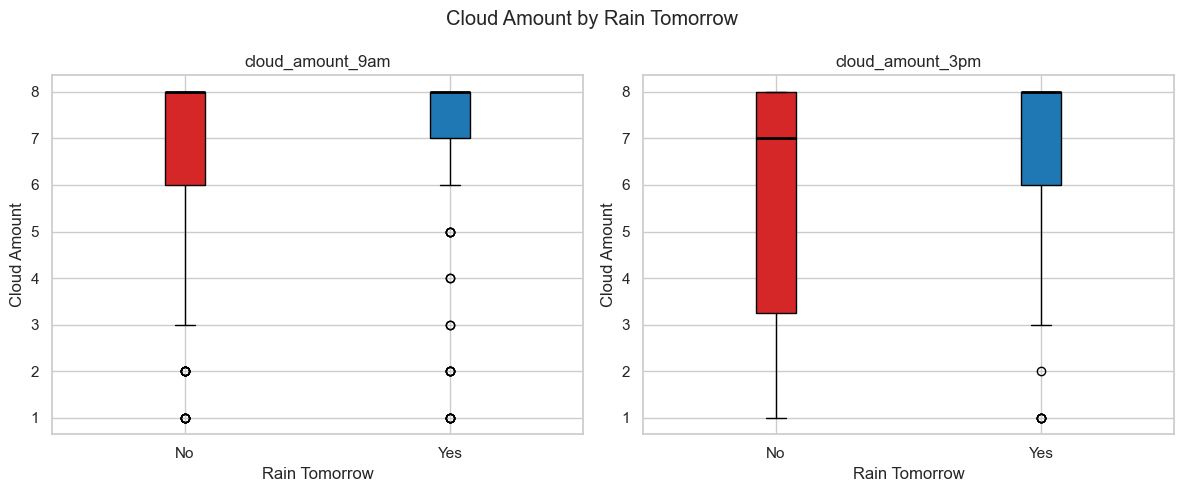

In [ ]:
# Define cloud amount variables
cloud_predictors = [
    "cloud_amount_9am",
    "cloud_amount_3pm"
]

# Create boxplots for observed cloud amount values by rain tomorrow outcome
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cloud_predictors):

    no_rain = data.loc[data["rain_tomorrow"] == 0, col].dropna()
    rain = data.loc[data["rain_tomorrow"] == 1, col].dropna()

    bp = ax.boxplot(
        [no_rain, rain],
        tick_labels=["No", "Yes"],
        patch_artist=True
    )

    bp["boxes"][0].set_facecolor("#d62728")
    bp["boxes"][1].set_facecolor("#1f77b4")

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    ax.set_title(col)
    ax.set_xlabel("Rain Tomorrow")
    ax.set_ylabel("Cloud Amount")

plt.suptitle("Cloud Amount by Rain Tomorrow")
plt.tight_layout()
plt.show()

The cloud amount variables show that days followed by rain are generally concentrated at higher cloud amount values, with both the 9am and 3pm distributions clustered toward the upper end of the scale. However, high cloud amount is not exclusive to rain days, as the no-rain group also contains many observations with substantial cloud cover and spans a much wider range overall.

This suggests that cloud amount may be useful for identifying conditions commonly present before rainfall, but it is unlikely to distinguish rain and no-rain outcomes on its own. In particular, low cloud amount appears more indicative of no rain, while high cloud amount alone does not necessarily imply rain the following day. The large proportion of missing values also means these variables should be treated cautiously during modelling, as their usefulness will depend on how missing data is handled.


### 4.3 Relationships Between Categorical Variables and Rain Tomorrow
The numeric analysis identified several weather measurements that appear to differ between rainfall and non-rainfall days. The next step is to investigate the categorical variables and determine whether particular wind directions are associated with an increased probability of rainfall on the following day.

Unlike the numeric variables, the categorical predictors cannot be compared using boxplots. Instead, the analysis will examine how the proportion of rainfall days varies across the observed wind direction categories.

In [ ]:
# Define compass order for wind direction categories
compass_order = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

# Define categorical wind direction predictors
categorical_predictors = [
    "max_wind_gust_direction",
    "wind_direction_9am",
    "wind_direction_3pm"
]

# Display count and rain tomorrow probability for each wind direction
for col in categorical_predictors:
    
    wind_summary = (
        data.groupby(col)["rain_tomorrow"]
            .agg(
                count="count",
                rain_tomorrow_probability="mean"
            )
            .reindex(compass_order)
            .dropna()
    )

    wind_summary["rain_tomorrow_probability"] = (
        wind_summary["rain_tomorrow_probability"] * 100
    ).round(1)

    display(Markdown(f"#### Rain tomorrow probability by {col}"))
    display(wind_summary)

#### Rain tomorrow probability by max_wind_gust_direction

,count,rain_tomorrow_probability
max_wind_gust_direction,,
N,34,52.900
NNE,18,44.400
NE,21,57.100
ENE,5,20.000
E,16,12.500
ESE,30,16.700
SE,16,0.000
SSE,14,14.300
S,9,0.000


#### Rain tomorrow probability by wind_direction_9am

,count,rain_tomorrow_probability
wind_direction_9am,,
N,55,47.300
NNE,55,45.500
NE,41,41.500
ENE,9,33.300
E,15,33.300
ESE,14,7.100
SE,15,6.700
SSE,14,14.300
S,21,19.000


#### Rain tomorrow probability by wind_direction_3pm

,count,rain_tomorrow_probability
wind_direction_3pm,,
N,18,61.100
NNE,10,60.000
NE,12,41.700
ENE,4,25.000
E,13,23.100
ESE,10,40.000
SE,16,12.500
SSE,6,0.000
S,17,11.800


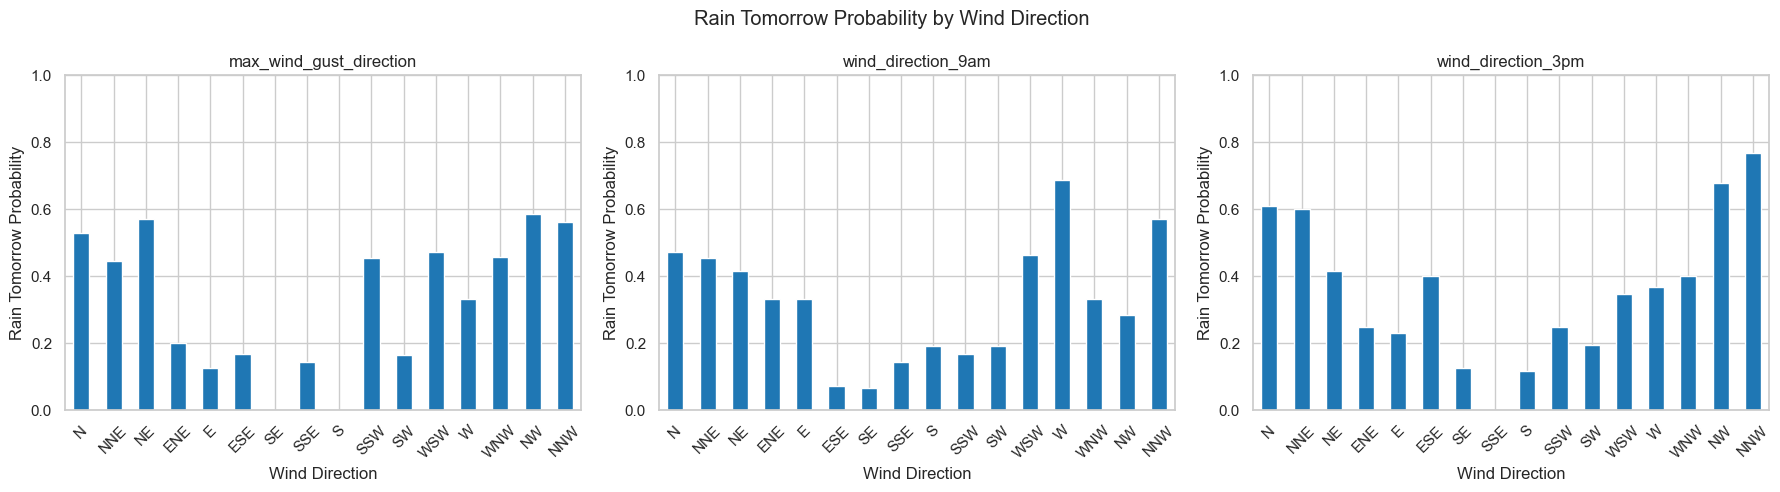

In [ ]:
# Plot rain tomorrow probability by wind direction using compass order
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax, col in zip(axes, categorical_predictors):

    rain_prob = (
        data.groupby(col)["rain_tomorrow"]
            .mean()
            .reindex(compass_order)
            .dropna()
    )

    rain_prob.plot(
        kind="bar",
        ax=ax,
        color="#1f77b4"
    )

    ax.set_title(col)
    ax.set_xlabel("Wind Direction")
    ax.set_ylabel("Rain Tomorrow Probability")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Rain Tomorrow Probability by Wind Direction")
plt.tight_layout()
plt.show()

The wind direction variables exhibit a reasonably consistent relationship with rainfall occurrence. Across all three measures, easterly and south-easterly wind directions generally correspond to lower probabilities of rainfall on the following day, while north-westerly and westerly directions tend to correspond to higher rainfall probabilities.

This pattern is particularly evident for the north-west (NW), north-north-west (NNW), and west-north-west (WNW) directions, which frequently show some of the highest rainfall probabilities across the three variables. In contrast, easterly directions such as E, ESE, SE, and SSE generally have some of the lowest rainfall probabilities.

Although some categories contain relatively small numbers of observations, many of the key directional groups have moderate sample sizes, suggesting that the observed pattern is not solely driven by a handful of observations. These results indicate that wind direction may provide useful predictive information for rainfall occurrence and should be retained for the modelling stage.

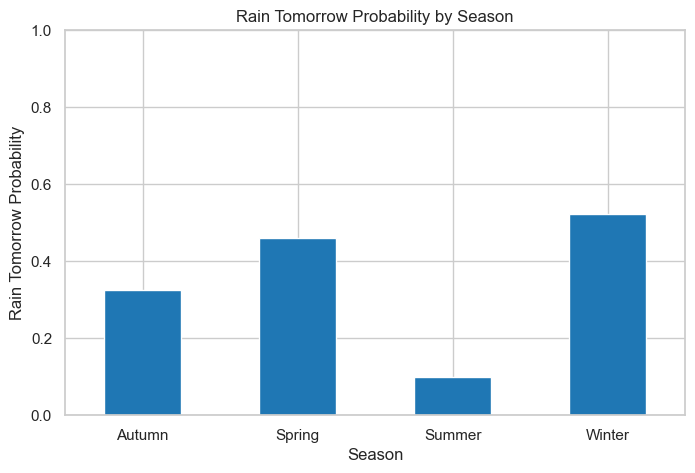

In [ ]:
# Calculate rainfall probability by season
season_prob = data.groupby("season")["rain_tomorrow"].mean()

# Plot rainfall probability by season
plt.figure(figsize=(8, 5))
season_prob.plot(kind="bar", color="#1f77b4")

plt.title("Rain Tomorrow Probability by Season")
plt.xlabel("Season")
plt.ylabel("Rain Tomorrow Probability")

plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

Seasonal effects appear to influence rainfall occurrence. Winter and spring exhibit higher probabilities of rainfall on the following day, while summer shows the lowest probability. This is consistent with the rainfall patterns observed earlier in the analysis and suggests that season-based features may provide useful predictive information.

### 4.4 Summary of Exploratory Data Analysis
The exploratory analysis identified several variables that appear to be associated with rainfall occurrence.

Seasonal rainfall patterns suggest that rainfall is not evenly distributed throughout the year, indicating that temporal features may provide useful predictive information. The rainfall distribution was highly right-skewed, with approximately 65% of days recording no rainfall.

The numeric predictor analysis revealed noticeable differences between rainfall and non-rainfall days for several variables. Humidity, temperature, atmospheric pressure, wind-related variables, and cloud amount all exhibited shifts in their distributions between the two groups, suggesting potential predictive value. However, the cloud amount variables contained a large proportion of missing values, meaning their contribution should be interpreted cautiously during modelling. Correlation analysis also revealed strong relationships between some predictors, particularly among temperature and pressure measurements, which may influence feature selection and model interpretation.

The categorical predictor analysis showed that both season and wind direction are associated with rainfall probability. Winter and spring exhibited higher probabilities of rainfall occurrence than summer, while north-westerly and westerly wind directions generally corresponded to higher rainfall probabilities than easterly and south-easterly directions.

Overall, the exploratory analysis suggests that both numerical and categorical weather variables contain useful information for predicting rainfall occurrence. These findings support the inclusion of the available predictors in the initial modelling stage, with model-based feature importance measures used later to assess their relative contributions and the impact of missing values.

## 5. Predictive Modelling

Following the exploratory data analysis, the next stage is to develop predictive models for the Rain Tomorrow outcome. The EDA identified several weather variables that appear to differ between rainfall and non-rainfall days, including humidity, temperature, pressure, wind conditions, and seasonality. However, visual patterns alone do not indicate how well these variables can predict rainfall when considered together.

Although cloud amount showed some relationship with the target variable, it was excluded from the main modelling dataset due to its large proportion of missing values and limited standalone separation between rainfall outcomes. This avoids relying on extensive imputation for variables where the observed predictive value is uncertain.

This section therefore focuses on building and evaluating classification models that use the remaining available weather predictors to estimate whether rainfall occurs on the following day. The modelling process includes preparing the data, handling missing values and categorical variables, fitting multiple model types, and comparing their performance using appropriate classification metrics.

### 5.1 Modelling Dataset Preparation
Before fitting any predictive models, a separate modelling dataframe is created from the cleaned dataset. This allows modelling-specific changes to be made without altering the original dataset used during exploratory analysis. Several engineered features are added to represent recent rainfall patterns, short-term atmospheric changes, and daily temperature variation that may provide additional predictive information.

The cloud amount variables are removed from the main modelling dataset due to their large proportion of missing values and uncertain additional predictive value. The `max_wind_gust_time` variable is also removed because it has very high cardinality, with many unique time values. If one-hot encoded directly, this variable would create a large number of sparse features, which is not ideal given the relatively small dataset size.

Although the timing of the maximum wind gust may contain useful information, it would require more appropriate time-based feature engineering, such as converting the time into cyclical features, before it could be represented effectively. For the purpose of the main modelling workflow, it is therefore excluded to keep the baseline models simpler and more interpretable.

A compact set of lagged, rolling, and weather-trend features is then created to represent recent rainfall persistence and changes in atmospheric conditions. These features use only the current completed observation row and earlier rows, while the prediction target remains two observation periods ahead.

In [ ]:
# Create a separate modelling dataframe
df_model = data.copy()

# Drop variables excluded from the main modelling dataset
drop_cols = [
    "cloud_amount_9am",
    "cloud_amount_3pm",
    "max_wind_gust_time"
]

df_model = df_model.drop(columns=drop_cols)

# Add recent rainfall persistence features
df_model["rainfall_lag_1"] = df_model["rainfall"].shift(1)
df_model["rainfall_3day_total"] = (
    df_model["rainfall"]
    .rolling(window=3, min_periods=3)
    .sum()
)
df_model["rainfall_7day_total"] = (
    df_model["rainfall"]
    .rolling(window=7, min_periods=7)
    .sum()
)
df_model["rainy_days_last_7"] = (
    df_model["rainfall"]
    .gt(0)
    .rolling(window=7, min_periods=7)
    .sum()
)

# Add atmospheric and temperature change features
df_model["pressure_change_intraday"] = (
    df_model["pressure_3pm"] - df_model["pressure_9am"]
)
df_model["pressure_change_1day"] = df_model["pressure_3pm"].diff()
df_model["humidity_change_intraday"] = (
    df_model["humidity_3pm"] - df_model["humidity_9am"]
)
df_model["temperature_range"] = (
    df_model["max_temp"] - df_model["min_temp"]
)

# Remove the initial rows without complete rolling history
df_model = df_model.iloc[6:].copy()

engineered_features = [
    "rainfall_lag_1",
    "rainfall_3day_total",
    "rainfall_7day_total",
    "rainy_days_last_7",
    "pressure_change_intraday",
    "pressure_change_1day",
    "humidity_change_intraday",
    "temperature_range",
]

# Check updated shape and engineered feature names
print("Original data shape:", data.shape)
print("Modelling data shape:", df_model.shape)
print("\nEngineered features:")
print(engineered_features)

Original data shape: (396, 22)
Modelling data shape: (390, 27)

Engineered features:
['rainfall_lag_1', 'rainfall_3day_total', 'rainfall_7day_total', 'rainy_days_last_7', 'pressure_change_intraday', 'pressure_change_1day', 'humidity_change_intraday', 'temperature_range']


### 5.2 Feature and Target Definition
The target variable for modelling is `rain_tomorrow`, which indicates whether rainfall was recorded during the next complete BoM rainfall observation period after the current day's observations. The predictor set includes the original retained weather variables and eight engineered features describing recent rainfall, pressure changes, humidity change, and temperature range.

The first six observations are removed because a complete seven-day rolling history is unavailable for them. Any remaining isolated missing values are retained at this stage and handled later within the preprocessing pipeline.


In [ ]:
# Define target column
target_col = "rain_tomorrow"

# Separate predictors and target
X = df_model.drop(columns=target_col)
y = df_model[target_col]

# Check feature and target dimensions
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Check remaining missing values in the predictors
missing_features = X.isna().sum()
missing_features = missing_features[missing_features > 0].sort_values(ascending=False)

missing_features

Feature matrix shape: (390, 26)
Target vector shape: (390,)


max_wind_gust_direction    2
max_wind_gust_speed        2
max_temp                   1
temperature_range          1
dtype: int64

### 5.3 Chronological Train-Test Split

Since the dataset is ordered through time, a chronological train-test split is used rather than a random split. This better reflects the forecasting problem, where the model should be trained on earlier observations and evaluated on later unseen observations.

The first 80% of observations are used for training, while the final 20% are held out as the test set. Since the target is shifted forward by the forecast horizon, a small gap equal to `forecast_horizon` is left between the training and testing periods. This prevents the final training labels from being constructed using rainfall values that fall inside the held-out test period.


In [ ]:
# Use a chronological train-test split with a forecast-horizon gap
split_idx = int(len(df_model) * 0.8)
train_end_idx = split_idx - forecast_horizon

X_train = X.iloc[:train_end_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:train_end_idx]
y_test = y.iloc[split_idx:]

print("Gap rows between training and testing:", forecast_horizon)

# Check split dimensions
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Gap rows between training and testing: 2
Training feature shape: (310, 26)
Testing feature shape: (78, 26)

Training target distribution:
rain_tomorrow
0   0.665
1   0.335
Name: proportion, dtype: Float64

Testing target distribution:
rain_tomorrow
0   0.590
1   0.410
Name: proportion, dtype: Float64


In [ ]:
# Identify numeric and categorical predictors from the training data
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 22
Number of categorical features: 4

Numeric features:
['min_temp', 'max_temp', 'rainfall', 'max_wind_gust_speed', 'temp_9am', 'humidity_9am', 'wind_speed_9am', 'pressure_9am', 'temp_3pm', 'humidity_3pm', 'wind_speed_3pm', 'pressure_3pm', 'month', 'day_of_year', 'rainfall_lag_1', 'rainfall_3day_total', 'rainfall_7day_total', 'rainy_days_last_7', 'pressure_change_intraday', 'pressure_change_1day', 'humidity_change_intraday', 'temperature_range']

Categorical features:
['max_wind_gust_direction', 'wind_direction_9am', 'wind_direction_3pm', 'season']


### 5.4 Model Training and Evaluation
Five principal classification models are fitted to predict the rain_tomorrow outcome using the prepared chronological training data. Each model is evaluated using time-series cross-validation, preserving temporal order and applying a validation gap equal to the forecast horizon. This gap prevents the final labels in each training fold from being constructed using rainfall values from the following validation fold.

The modelling begins with an unregularised logistic regression as a simple baseline, using all remaining predictors without manually specified interaction terms. A class-balanced variation is also inspected as a sensitivity check, but it is not treated as a separate model family in the main five-model comparison.

Lasso and Ridge logistic regression models are then fitted as regularised alternatives. Lasso can shrink less useful coefficients to zero, while Ridge retains all predictors and reduces the magnitude of correlated coefficients. Comparing them helps assess whether feature selection or coefficient shrinkage is more suitable for the correlated weather variables.

Random forest and XGBoost are fitted as more flexible tree-based approaches. These models can capture nonlinear relationships and interactions between predictors without requiring interaction terms to be manually specified. Unlike the logistic regression models, tree-based models do not require numeric predictors to be standardised, although missing values and categorical predictors still need to be handled appropriately.



Before fitting the models, separate preprocessing pipelines are defined for linear and tree-based approaches. Missing numeric values are replaced using the median, while missing categorical values are replaced with the most frequent category and one-hot encoded. Numeric predictors are standardised for logistic regression models but left unscaled for tree-based models.

A reusable evaluation function is also defined to apply the same assessment process to each model. It calculates accuracy, balanced accuracy, precision, rain recall, specificity, F1 score, F2 score, MCC, and ROC-AUC. MCC accounts for all four outcomes in the confusion matrix and provides a useful single measure of overall classification quality, while the remaining metrics show the trade-off between identifying rain and no-rain periods.

In [ ]:
# Numeric preprocessing for logistic regression models
linear_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Numeric preprocessing for tree-based models
tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Categorical preprocessing shared by all models
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Preprocessor for logistic regression models
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", linear_numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

# Preprocessor for tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", tree_numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

In [ ]:
# Reusable function for evaluating classification models
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Specificity": recall_score(
            y_test,
            y_pred,
            pos_label=0,
            zero_division=0,
        ),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "F2 Score": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }

    display(Markdown(f"### {model_name} Results"))
    display(pd.DataFrame([metrics]).set_index("Model"))
    print(f"Classification threshold: {threshold:.2f}")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Rain", "Rain"],
        cmap="Blues",
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{model_name} ROC Curve")
    plt.show()

    return metrics

In [ ]:
# F2 scorer prioritises rain recall while still accounting for precision
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
mcc_scorer = make_scorer(matthews_corrcoef)

# Reusable time-series cross-validation function
def evaluate_cross_validation(model, X, y, model_name, cv):
    scoring = {
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Precision": make_scorer(
            precision_score,
            zero_division=0,
        ),
        "Recall": "recall",
        "Specificity": make_scorer(
            recall_score,
            pos_label=0,
            zero_division=0,
        ),
        "F1 Score": "f1",
        "F2 Score": f2_scorer,
        "ROC-AUC": "roc_auc",
        "MCC": mcc_scorer,
    }

    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
    )

    fold_results = pd.DataFrame({
        metric: cv_scores[f"test_{metric}"]
        for metric in scoring
    })

    fold_results.index = range(1, len(fold_results) + 1)
    fold_results.index.name = "Fold"

    summary = pd.DataFrame({
        "Mean": fold_results.mean(),
        "Standard Deviation": fold_results.std(),
    })

    display(Markdown(f"### {model_name} Cross-Validation Results"))
    display(fold_results)

    display(Markdown("### Cross-Validation Summary"))
    display(summary)

    return summary


# Reusable function for comparing cross-validation summaries
def compare_cross_validation_summaries(cv_summaries):
    comparison = pd.DataFrame({
        model_name: {
            **results["Mean"].to_dict(),
            "MCC Standard Deviation": results.loc[
                "MCC",
                "Standard Deviation",
            ],
        }
        for model_name, results in cv_summaries.items()
    }).T.sort_values("MCC", ascending=False)

    return comparison[
        [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1 Score",
            "F2 Score",
            "ROC-AUC",
            "MCC",
            "MCC Standard Deviation",
        ]
    ]

### 5.4.1 Baseline Logistic Regression

In [ ]:
# Define time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5, gap=forecast_horizon)

# Build baseline logistic regression pipeline
baseline_logistic_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(
            penalty=None,
            max_iter=1000,
            random_state=42,
        )),
    ]
)

# Evaluate across training periods
baseline_logistic_cv_results = evaluate_cross_validation(
    model=baseline_logistic_model,
    X=X_train,
    y=y_train,
    model_name="Baseline Logistic Regression",
    cv=tscv,
)

### Baseline Logistic Regression Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.510,0.517,0.500,0.880,0.154,0.638,0.764,0.680,0.049
2,0.627,0.599,0.700,0.304,0.893,0.424,0.343,0.505,0.247
3,0.510,0.515,0.538,0.269,0.760,0.359,0.299,0.586,0.034
4,0.451,0.720,0.034,1.000,0.440,0.067,0.152,0.480,0.123
5,0.804,0.578,0.333,0.250,0.907,0.286,0.263,0.605,0.177


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.580,0.140
Balanced Accuracy,0.586,0.084
Precision,0.421,0.252
Recall,0.541,0.367
Specificity,0.631,0.326
F1 Score,0.355,0.208
F2 Score,0.364,0.234
ROC-AUC,0.571,0.081
MCC,0.126,0.089


The baseline logistic regression provides an interpretable reference point for the regularised and tree-based models. Its MCC, balanced accuracy, rain recall, specificity, ROC-AUC, and variation across folds should be considered together rather than relying on overall accuracy alone. A class-balanced variation is also inspected to assess whether weighting the rain class changes this trade-off.

In [ ]:
# Build class-balanced logistic regression pipeline
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(
            penalty=None,
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

# Evaluate across training periods
balanced_logistic_cv_results = evaluate_cross_validation(
    model=balanced_logistic_model,
    X=X_train,
    y=y_train,
    model_name="Class-Balanced Logistic Regression",
    cv=tscv,
)

### Class-Balanced Logistic Regression Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.549,0.556,0.523,0.920,0.192,0.667,0.799,0.680,0.163
2,0.627,0.599,0.700,0.304,0.893,0.424,0.343,0.500,0.247
3,0.529,0.534,0.571,0.308,0.760,0.400,0.339,0.609,0.076
4,0.431,0.220,0.000,0.000,0.440,0.000,0.000,0.440,-0.156
5,0.784,0.567,0.286,0.250,0.884,0.267,0.256,0.608,0.141


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.584,0.132
Balanced Accuracy,0.495,0.156
Precision,0.416,0.277
Recall,0.356,0.340
Specificity,0.634,0.307
F1 Score,0.352,0.244
F2 Score,0.347,0.288
ROC-AUC,0.567,0.096
MCC,0.094,0.153


The class-balanced logistic regression is treated as a sensitivity check rather than a separate model family. Compared with the standard baseline logistic regression, the class-balanced version does not provide a stronger overall result across the main evaluation metrics. This suggests that simply weighting the outcome classes is not enough to improve model performance for this dataset.

### 5.4.2 Lasso Logistic Regression

In [ ]:
# Build Lasso logistic regression pipeline
lasso_logistic_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=1000,
            random_state=42,
        )),
    ]
)

# Evaluate across training periods
lasso_logistic_cv_results = evaluate_cross_validation(
    model=lasso_logistic_model,
    X=X_train,
    y=y_train,
    model_name="Lasso Logistic Regression",
    cv=tscv,
)

### Lasso Logistic Regression Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.569,0.576,0.533,0.960,0.192,0.686,0.828,0.680,0.236
2,0.627,0.626,0.583,0.609,0.643,0.596,0.603,0.654,0.251
3,0.529,0.535,0.600,0.231,0.840,0.333,0.263,0.597,0.089
4,0.216,0.600,0.024,1.000,0.200,0.048,0.111,0.240,0.070
5,0.804,0.477,0.000,0.000,0.953,0.000,0.000,0.392,-0.087


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.549,0.214
Balanced Accuracy,0.563,0.058
Precision,0.348,0.308
Recall,0.560,0.441
Specificity,0.566,0.355
F1 Score,0.332,0.311
F2 Score,0.361,0.346
ROC-AUC,0.513,0.190
MCC,0.112,0.138


Lasso applies L1 regularisation and can remove predictors by shrinking their coefficients to zero. Its results should be compared with Ridge to determine whether sparse feature selection or retaining correlated weather predictors produces stronger and more stable classification.

### 5.4.3 Ridge Logistic Regression

In [ ]:
# Build Ridge logistic regression pipeline
ridge_logistic_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=1000,
            random_state=42,
        )),
    ]
)

# Evaluate across training periods
ridge_logistic_cv_results = evaluate_cross_validation(
    model=ridge_logistic_model,
    X=X_train,
    y=y_train,
    model_name="Ridge Logistic Regression",
    cv=tscv,
)

### Ridge Logistic Regression Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.510,0.517,0.500,0.880,0.154,0.638,0.764,0.715,0.049
2,0.647,0.624,0.692,0.391,0.857,0.500,0.429,0.562,0.284
3,0.529,0.536,0.625,0.192,0.880,0.294,0.223,0.605,0.099
4,0.216,0.600,0.024,1.000,0.200,0.048,0.111,0.300,0.070
5,0.843,0.500,0.000,0.000,1.000,0.000,0.000,0.390,0.000


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.549,0.229
Balanced Accuracy,0.555,0.054
Precision,0.368,0.332
Recall,0.493,0.433
Specificity,0.618,0.407
F1 Score,0.296,0.277
F2 Score,0.305,0.301
ROC-AUC,0.514,0.168
MCC,0.100,0.109


Ridge logistic regression retains all predictors while shrinking their coefficients, which may be beneficial when weather variables contain overlapping information. Its cross-validation MCC, balanced accuracy, rain recall, specificity, ROC-AUC, and fold-to-fold variation should be compared with Lasso to assess whether retaining correlated predictors improves temporal generalisation.

### 5.4.4 Random Forest

In [ ]:
# Build random forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
        )),
    ]
)

# Evaluate across training periods
random_forest_cv_results = evaluate_cross_validation(
    model=random_forest_model,
    X=X_train,
    y=y_train,
    model_name="Random Forest",
    cv=tscv,
)

### Random Forest Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.569,0.573,0.541,0.800,0.346,0.645,0.730,0.622,0.164
2,0.647,0.648,0.600,0.652,0.643,0.625,0.641,0.710,0.294
3,0.529,0.532,0.550,0.423,0.640,0.478,0.444,0.528,0.065
4,0.314,0.650,0.028,1.000,0.300,0.054,0.125,0.660,0.091
5,0.824,0.488,0.000,0.000,0.977,0.000,0.000,0.436,-0.061


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.576,0.185
Balanced Accuracy,0.578,0.071
Precision,0.344,0.302
Recall,0.575,0.384
Specificity,0.581,0.273
F1 Score,0.360,0.312
F2 Score,0.388,0.318
ROC-AUC,0.591,0.109
MCC,0.110,0.131


Random forest provides a nonlinear comparison with the logistic regression models and can capture interactions between weather predictors. Its mean MCC and stability across folds will indicate whether this flexibility improves classification or instead overfits the limited training periods.

### 5.4.5 XGBoost

In [ ]:
# Build XGBoost pipeline
xgboost_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            eval_metric="logloss",
            random_state=42,
        )),
    ]
)

# Evaluate across training periods
xgboost_cv_results = evaluate_cross_validation(
    model=xgboost_model,
    X=X_train,
    y=y_train,
    model_name="XGBoost",
    cv=tscv,
)

### XGBoost Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.608,0.614,0.561,0.920,0.308,0.697,0.816,0.517,0.287
2,0.667,0.673,0.607,0.739,0.607,0.667,0.708,0.744,0.346
3,0.451,0.455,0.438,0.269,0.640,0.333,0.292,0.497,-0.098
4,0.373,0.680,0.030,1.000,0.360,0.059,0.135,0.360,0.104
5,0.843,0.500,0.000,0.000,1.000,0.000,0.000,0.401,0.000


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.588,0.185
Balanced Accuracy,0.584,0.102
Precision,0.327,0.292
Recall,0.586,0.433
Specificity,0.583,0.275
F1 Score,0.351,0.327
F2 Score,0.390,0.357
ROC-AUC,0.504,0.149
MCC,0.128,0.188


XGBoost provides a second nonlinear approach that builds trees sequentially to correct earlier errors. Its MCC, rain recall, specificity, ROC-AUC, and fold variability should be compared with Random Forest and the linear models before deciding whether it warrants hyperparameter tuning.

### 5.4.6 Initial Model Comparison

In [ ]:
# Combine cross-validation summaries for model comparison
model_cv_summaries = {
    "Baseline Logistic Regression": baseline_logistic_cv_results,
    "Lasso Logistic Regression": lasso_logistic_cv_results,
    "Ridge Logistic Regression": ridge_logistic_cv_results,
    "Random Forest": random_forest_cv_results,
    "XGBoost": xgboost_cv_results,
}

model_comparison = compare_cross_validation_summaries(
    model_cv_summaries
)

display(Markdown("### Models Cross-Validation Performance"))
display(model_comparison)

### Models Cross-Validation Performance

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC,MCC Standard Deviation
XGBoost,0.588,0.584,0.327,0.586,0.583,0.351,0.390,0.504,0.128,0.188
Baseline Logistic Regression,0.580,0.586,0.421,0.541,0.631,0.355,0.364,0.571,0.126,0.089
Lasso Logistic Regression,0.549,0.563,0.348,0.560,0.566,0.332,0.361,0.513,0.112,0.138
Random Forest,0.576,0.578,0.344,0.575,0.581,0.360,0.388,0.591,0.110,0.131
Ridge Logistic Regression,0.549,0.555,0.368,0.493,0.618,0.296,0.305,0.514,0.100,0.109


XGBoost, Lasso logistic regression, and Random Forest are selected for hyperparameter tuning. XGBoost achieved the highest mean MCC in the initial comparison, although its MCC varied substantially across folds. Lasso is retained as the strongest regularised linear model and provides a useful comparison against the nonlinear tree-based approaches.

Random Forest is selected as the third tuning candidate because it produced similar mean MCC to Lasso while achieving stronger accuracy, balanced accuracy, rain recall, specificity, F1 score, F2 score, ROC-AUC, and slightly lower MCC variability. Although the unregularised baseline achieved the highest mean ROC-AUC and strong MCC stability, it is treated as a reference model rather than a main tuning candidate. Ridge was not carried forward because its mean MCC and rain recall were lower than the shortlisted alternatives.

### 5.5 Hyperparameter Tuning and Model Selection
XGBoost, Lasso logistic regression, and Random Forest are tuned using the same time-series cross-validation strategy applied during the initial comparison. Hyperparameters are selected by maximising MCC, which accounts for all four confusion-matrix outcomes and discourages models from collapsing toward either outcome class. Rain recall, specificity, balanced accuracy, and MCC variability remain important supporting measures.

The strongest tuned model will then be fitted using the complete training set and evaluated on the held-out test period.

#### 5.5.1 XGBoost Tuning

In [ ]:
# Define XGBoost hyperparameters to test
xgboost_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
}

# Tune using time-series cross-validation
xgboost_grid_search = GridSearchCV(
    estimator=xgboost_model,
    param_grid=xgboost_param_grid,
    scoring=mcc_scorer,
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

xgboost_grid_search.fit(X_train, y_train)

# Display best tuning result
print("Best parameters:", xgboost_grid_search.best_params_)
print(f"Best mean cross-validation MCC: {xgboost_grid_search.best_score_:.3f}")

# Retrieve the best fitted pipeline
tuned_xgboost_model = xgboost_grid_search.best_estimator_

# Evaluate the tuned model across the same time-series folds
tuned_xgboost_cv_results = evaluate_cross_validation(
    model=tuned_xgboost_model,
    X=X_train,
    y=y_train,
    model_name="Tuned XGBoost",
    cv=tscv,
)

Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best mean cross-validation MCC: 0.145


### Tuned XGBoost Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.569,0.574,0.538,0.840,0.308,0.656,0.755,0.555,0.174
2,0.706,0.705,0.667,0.696,0.714,0.681,0.690,0.748,0.409
3,0.510,0.513,0.529,0.346,0.680,0.419,0.372,0.509,0.028
4,0.353,0.670,0.029,1.000,0.340,0.057,0.132,0.360,0.100
5,0.824,0.488,0.000,0.000,0.977,0.000,0.000,0.358,-0.061


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.592,0.181
Balanced Accuracy,0.590,0.095
Precision,0.353,0.314
Recall,0.576,0.403
Specificity,0.604,0.280
F1 Score,0.363,0.322
F2 Score,0.390,0.333
ROC-AUC,0.506,0.162
MCC,0.130,0.178


XGBoost is tuned by varying tree depth, learning rate, number of estimators, subsampling, and feature sampling. The selected configuration maximises mean cross-validation MCC, while the full metric table should be reviewed to determine whether the stronger initial MCC is maintained consistently across time periods.

#### 5.5.2 Lasso Logistic Regression Tuning

In [ ]:
# Define Lasso hyperparameters to test
lasso_param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
}

# Tune using time-series cross-validation
lasso_grid_search = GridSearchCV(
    estimator=lasso_logistic_model,
    param_grid=lasso_param_grid,
    scoring=mcc_scorer,
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

lasso_grid_search.fit(X_train, y_train)

# Display best tuning result
print("Best parameters:", lasso_grid_search.best_params_)
print(f"Best mean cross-validation MCC: {lasso_grid_search.best_score_:.3f}")

# Retrieve the best fitted pipeline
tuned_lasso_model = lasso_grid_search.best_estimator_

# Evaluate the tuned model across the same time-series folds
tuned_lasso_cv_results = evaluate_cross_validation(
    model=tuned_lasso_model,
    X=X_train,
    y=y_train,
    model_name="Tuned Lasso Logistic Regression",
    cv=tscv,
)

Best parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Best mean cross-validation MCC: 0.253


### Tuned Lasso Logistic Regression Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.647,0.653,0.585,0.960,0.346,0.727,0.851,0.750,0.385
2,0.647,0.671,0.568,0.913,0.429,0.700,0.814,0.668,0.381
3,0.588,0.581,0.556,0.962,0.200,0.704,0.839,0.634,0.251
4,0.157,0.570,0.023,1.000,0.140,0.044,0.104,0.660,0.056
5,0.843,0.551,0.500,0.125,0.977,0.200,0.147,0.413,0.191


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.576,0.254
Balanced Accuracy,0.605,0.053
Precision,0.446,0.239
Recall,0.792,0.374
Specificity,0.418,0.333
F1 Score,0.475,0.327
F2 Score,0.551,0.389
ROC-AUC,0.625,0.126
MCC,0.253,0.138


Lasso is tuned by varying the strength of L1 regularisation and whether class weighting is applied. MCC is used to select the configuration that provides the strongest overall classification balance, while recall, specificity, and fold variability remain important for interpretation.

#### 5.5.3 Random Forest Tuning

In [ ]:
# Define Random Forest hyperparameters to test
random_forest_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", 0.5],
    "classifier__class_weight": [None, "balanced"],
}

# Tune using time-series cross-validation
random_forest_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=random_forest_param_grid,
    scoring=mcc_scorer,
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

random_forest_grid_search.fit(X_train, y_train)

# Display best tuning result
print("Best parameters:", random_forest_grid_search.best_params_)
print(f"Best mean cross-validation MCC: {random_forest_grid_search.best_score_:.3f}")

# Retrieve the best fitted pipeline
tuned_random_forest_model = random_forest_grid_search.best_estimator_

# Evaluate the tuned model across the same time-series folds
tuned_random_forest_cv_results = evaluate_cross_validation(
    model=tuned_random_forest_model,
    X=X_train,
    y=y_train,
    model_name="Tuned Random Forest",
    cv=tscv,
)

Best parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Best mean cross-validation MCC: 0.176


### Tuned Random Forest Cross-Validation Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC
Fold,,,,,,,,,
1,0.667,0.670,0.618,0.840,0.500,0.712,0.784,0.611,0.361
2,0.667,0.673,0.607,0.739,0.607,0.667,0.708,0.697,0.346
3,0.510,0.515,0.538,0.269,0.760,0.359,0.299,0.509,0.034
4,0.510,0.750,0.038,1.000,0.500,0.074,0.167,0.700,0.139
5,0.843,0.500,0.000,0.000,1.000,0.000,0.000,0.349,0.000


### Cross-Validation Summary

,Mean,Standard Deviation
Accuracy,0.639,0.138
Balanced Accuracy,0.622,0.109
Precision,0.360,0.313
Recall,0.570,0.419
Specificity,0.673,0.211
F1 Score,0.362,0.328
F2 Score,0.392,0.341
ROC-AUC,0.573,0.148
MCC,0.176,0.170


Random Forest is tuned by varying model size, tree depth, minimum leaf size, feature sampling, and class weighting. This tests whether a more constrained or class-weighted forest improves MCC and stability compared with the untuned model.

#### 5.5.4 Tuned Model Comparison and Selection

In [ ]:
# Compare tuned model cross-validation performance
tuned_model_cv_summaries = {
    "Tuned XGBoost": tuned_xgboost_cv_results,
    "Tuned Lasso Logistic Regression": tuned_lasso_cv_results,
    "Tuned Random Forest": tuned_random_forest_cv_results,
}

tuned_model_comparison = compare_cross_validation_summaries(
    tuned_model_cv_summaries
)

display(Markdown("### Tuned Models Cross-Validation Performance"))
display(tuned_model_comparison)

# Select the model with the highest mean cross-validation MCC
tuned_models = {
    "Tuned XGBoost": tuned_xgboost_model,
    "Tuned Lasso Logistic Regression": tuned_lasso_model,
    "Tuned Random Forest": tuned_random_forest_model,
}

final_model_name = tuned_model_comparison["MCC"].idxmax()
final_model = tuned_models[final_model_name]

print(f"Selected final model: {final_model_name}")

### Tuned Models Cross-Validation Performance

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,ROC-AUC,MCC,MCC Standard Deviation
Tuned Lasso Logistic Regression,0.576,0.605,0.446,0.792,0.418,0.475,0.551,0.625,0.253,0.138
Tuned Random Forest,0.639,0.622,0.360,0.570,0.673,0.362,0.392,0.573,0.176,0.170
Tuned XGBoost,0.592,0.590,0.353,0.576,0.604,0.363,0.390,0.506,0.130,0.178


Selected final model: Tuned Lasso Logistic Regression


The tuned models are compared using mean MCC as the primary selection metric, with MCC standard deviation, balanced accuracy, rain recall, specificity, and ROC-AUC used as supporting evidence. The model with the strongest mean cross-validation MCC is selected as the final model, provided its performance is not driven by an extreme imbalance between rain and no-rain predictions.

#### 5.5.5 Classification Threshold Selection

Following final model selection, classification thresholds are compared using the time-series validation folds to determine whether the default threshold of 0.50 provides the best overall classification balance. Mean MCC is used as the primary comparison metric, with rain recall used only to distinguish thresholds with effectively equal MCC. The held-out test period is not used during threshold selection.

### Leading Classification Thresholds

,Threshold,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,MCC
0,0.500,0.605,0.446,0.792,0.418,0.475,0.551,0.253
1,0.510,0.604,0.456,0.735,0.472,0.463,0.517,0.221
2,0.490,0.567,0.424,0.808,0.326,0.460,0.549,0.177
3,0.480,0.558,0.373,0.808,0.309,0.453,0.546,0.151
4,0.520,0.568,0.440,0.598,0.537,0.385,0.405,0.132
5,0.470,0.545,0.366,0.808,0.281,0.447,0.542,0.125
6,0.460,0.541,0.363,0.808,0.274,0.445,0.541,0.119
7,0.450,0.535,0.361,0.808,0.263,0.443,0.540,0.110
8,0.600,0.593,0.236,0.418,0.768,0.239,0.259,0.100
9,0.550,0.561,0.418,0.484,0.638,0.277,0.300,0.096


Selected classification threshold: 0.50


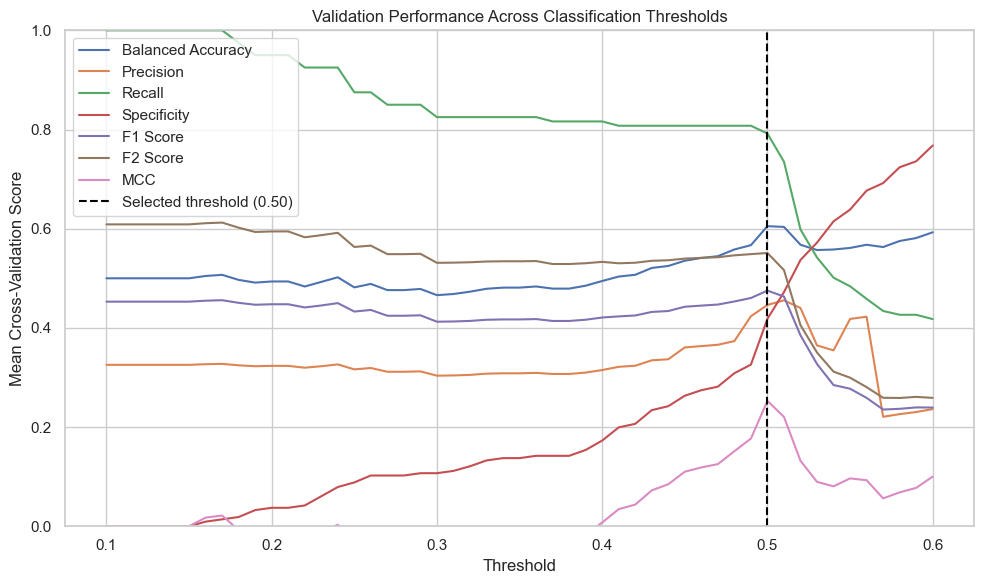

In [ ]:
# Generate validation probabilities without using the held-out test period
fold_predictions = []

for train_index, validation_index in tscv.split(X_train):
    fold_model = clone(final_model)
    fold_model.fit(
        X_train.iloc[train_index],
        y_train.iloc[train_index],
    )

    validation_probability = fold_model.predict_proba(
        X_train.iloc[validation_index]
    )[:, 1]

    fold_predictions.append((
        y_train.iloc[validation_index].to_numpy(),
        validation_probability,
    ))

# Compare candidate thresholds using mean performance across folds
threshold_records = []

for threshold in np.arange(0.10, 0.61, 0.01):
    fold_metrics = []

    for y_validation, validation_probability in fold_predictions:
        validation_prediction = (
            validation_probability >= threshold
        ).astype(int)

        fold_metrics.append({
            "Balanced Accuracy": balanced_accuracy_score(
                y_validation,
                validation_prediction,
            ),
            "Precision": precision_score(
                y_validation,
                validation_prediction,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_validation,
                validation_prediction,
                zero_division=0,
            ),
            "Specificity": recall_score(
                y_validation,
                validation_prediction,
                pos_label=0,
                zero_division=0,
            ),
            "F1 Score": f1_score(
                y_validation,
                validation_prediction,
                zero_division=0,
            ),
            "F2 Score": fbeta_score(
                y_validation,
                validation_prediction,
                beta=2,
                zero_division=0,
            ),
            "MCC": matthews_corrcoef(
                y_validation,
                validation_prediction,
            ),
        })

    mean_metrics = pd.DataFrame(fold_metrics).mean()
    threshold_records.append({
        "Threshold": threshold,
        **mean_metrics.to_dict(),
    })

threshold_results = pd.DataFrame(threshold_records)

# Maximise MCC, using rain recall as the tie-breaker
threshold_results["MCC (rounded)"] = (
    threshold_results["MCC"].round(3)
)

ranked_thresholds = threshold_results.sort_values(
    ["MCC (rounded)", "Recall", "Balanced Accuracy"],
    ascending=False,
)

selected_threshold = ranked_thresholds.iloc[0]["Threshold"]

display(Markdown("### Leading Classification Thresholds"))
display(
    ranked_thresholds
    .drop(columns="MCC (rounded)")
    .head(10)
    .reset_index(drop=True)
)
print(f"Selected classification threshold: {selected_threshold:.2f}")

# Visualise the threshold trade-off
threshold_results.plot(
    x="Threshold",
    y=[
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "F2 Score",
        "MCC",
    ],
    figsize=(10, 6),
)
plt.axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label=f"Selected threshold ({selected_threshold:.2f})",
)
plt.title("Validation Performance Across Classification Thresholds")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

The default threshold of 0.50 achieved the highest mean validation MCC at 0.253 and was therefore retained. Thresholds below 0.50 slightly increased rain recall, but this came with lower specificity and weaker MCC, meaning the model became less balanced overall. Thresholds above 0.50 improved specificity but reduced rain recall. The default threshold therefore provided the strongest validation balance between identifying rainy periods and correctly classifying no-rain periods.

### 5.6 Final Model Evaluation and Interpretation

With the final model selected, it is fitted using the complete training dataset and evaluated on the held-out test period. The classification threshold chosen from the validation folds is applied without using the test set during model selection. This final evaluation assesses how well the selected model generalises to later unseen observations, with particular attention given to MCC, balanced accuracy, rain recall, specificity, and false-negative predictions.

### Tuned Lasso Logistic Regression Results

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,F2 Score,MCC,ROC-AUC
Model,,,,,,,,,
Tuned Lasso Logistic Regression,0.782,0.744,0.895,0.531,0.957,0.667,0.578,0.559,0.787


Classification threshold: 0.50
Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.96      0.84        46
         1.0       0.89      0.53      0.67        32

    accuracy                           0.78        78
   macro avg       0.82      0.74      0.75        78
weighted avg       0.81      0.78      0.77        78



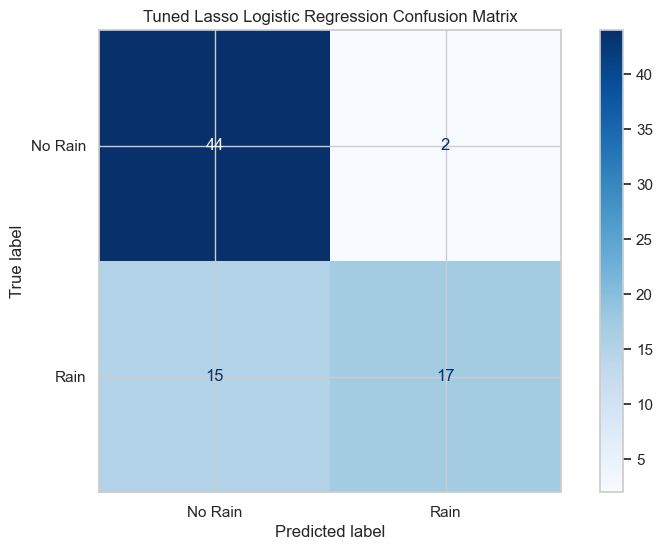

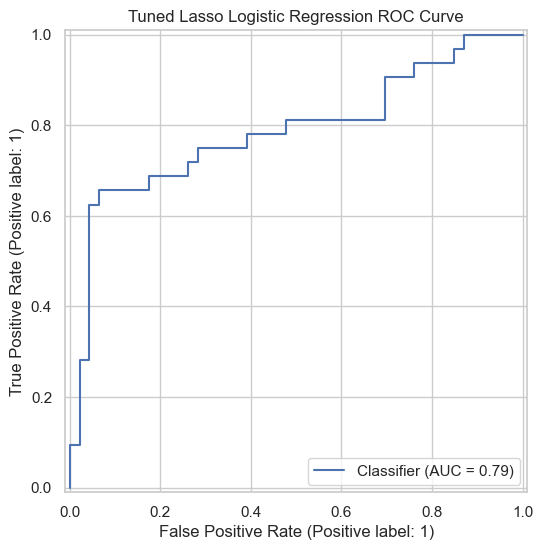

In [ ]:
# Fit the selected model using the complete training dataset
final_model.fit(X_train, y_train)

# Evaluate on the held-out test period
final_test_results = evaluate_model(
    model=final_model,
    X_test=X_test,
    y_test=y_test,
    model_name=final_model_name,
    threshold=selected_threshold,
)

The final tuned Lasso logistic regression achieved an accuracy of 0.782, balanced accuracy of 0.744, MCC of 0.559, and ROC-AUC of 0.787 on the held-out test period. Its test MCC was higher than the mean cross-validation MCC, suggesting that the final test period was handled better than the average validation fold, although the cross-validation results still show that performance varied across time periods.

The model performed particularly well at identifying no-rain periods, correctly classifying 44 of the 46 no-rain observations. It was less effective at identifying rainy periods, correctly classifying 17 of the 32 rain observations and missing 15. This produced high rain precision of 0.895 and specificity of 0.957, but lower rain recall of 0.531. Overall, the model provides a useful improvement over a naive classification approach, but missed rainfall events remain its main limitation.

#### 5.6.1 Predictor Importance

In [ ]:
# Extract transformed feature names
feature_names = (
    final_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

classifier = final_model.named_steps["classifier"]

if hasattr(classifier, "coef_"):
    predictor_effects = pd.DataFrame({
        "Feature": feature_names,
        "Effect": classifier.coef_[0],
    })
    predictor_effects["Absolute Effect"] = predictor_effects["Effect"].abs()
    predictor_effects["Direction"] = np.where(
        predictor_effects["Effect"] > 0,
        "Higher rain probability",
        np.where(
            predictor_effects["Effect"] < 0,
            "Lower rain probability",
            "No contribution",
        ),
    )
    effect_label = "Standardised Logistic Regression Coefficient"
    plot_title = "Largest Logistic Regression Coefficients"
elif hasattr(classifier, "feature_importances_"):
    predictor_effects = pd.DataFrame({
        "Feature": feature_names,
        "Effect": classifier.feature_importances_,
    })
    predictor_effects["Absolute Effect"] = predictor_effects["Effect"]
    predictor_effects["Direction"] = "Feature importance"
    effect_label = "Feature Importance"
    plot_title = "Largest Tree-Based Feature Importances"
else:
    raise TypeError("The selected model does not expose coefficients or feature importances.")

# Remove preprocessing prefixes for readability
predictor_effects["Feature"] = (
    predictor_effects["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

predictor_effects = predictor_effects.sort_values(
    "Absolute Effect",
    ascending=False,
).reset_index(drop=True)

non_zero_effects = (predictor_effects["Effect"] != 0).sum()
zero_effects = (predictor_effects["Effect"] == 0).sum()

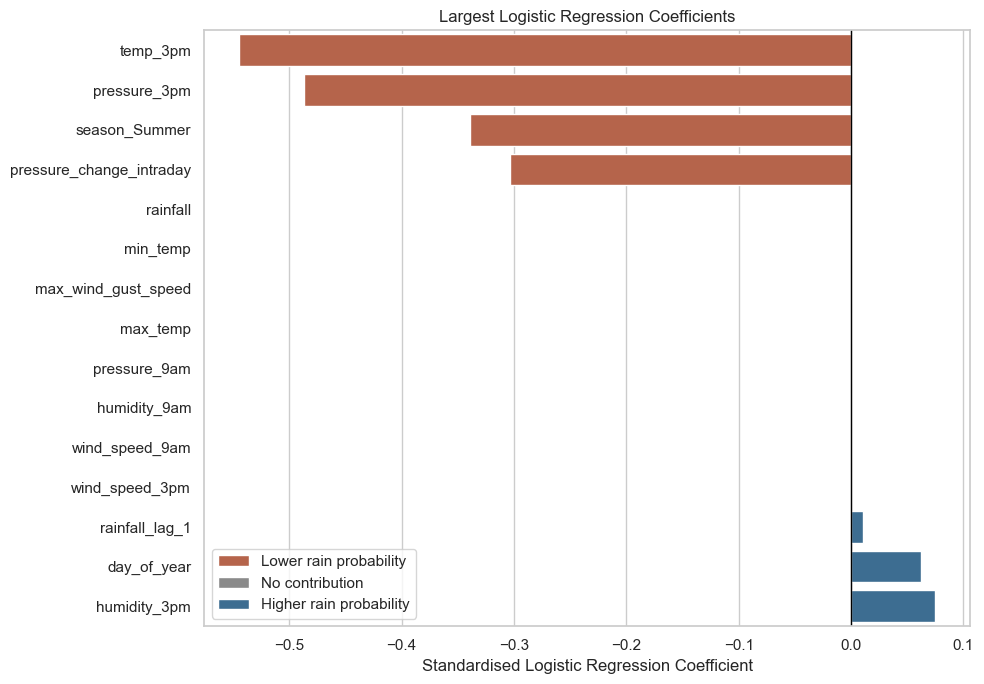

Non-zero effects: 7
Effects reduced to zero: 68


In [ ]:
# Plot predictors with the largest effects
top_predictors = (
    predictor_effects.head(15)
    .sort_values("Effect")
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_predictors,
    x="Effect",
    y="Feature",
    hue="Direction",
    dodge=False,
    palette={
        "Higher rain probability": "#2f6f9f",
        "Lower rain probability": "#c75b39",
        "No contribution": "#8a8a8a",
        "Feature importance": "#2f6f9f",
    },
)

plt.axvline(0, color="black", linewidth=1)
plt.title(plot_title)
plt.xlabel(effect_label)
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

print(f"Non-zero effects: {non_zero_effects}")
print(f"Effects reduced to zero: {zero_effects}")

The final Lasso model retained only 7 non-zero predictor effects, while 68 transformed predictors were reduced to zero. This indicates that the model relied on a relatively small subset of the available weather information when making predictions.

The strongest positive effect was associated with higher 3pm humidity, meaning that higher afternoon humidity increased the predicted probability of rain in the next BoM rainfall observation period. This is meteorologically sensible, as higher relative humidity indicates air closer to saturation. In contrast, higher 3pm temperature had one of the strongest negative effects, suggesting that warmer afternoon conditions were associated with a lower probability of subsequent rainfall.

An interesting result is that `day_of_year` was retained while the broader `season` categories were not, suggesting that the model found more value in the finer timing of the year than in the four broad seasonal labels. None of the 9am variables were retained, while only selected 3pm variables contributed to the final model. Current-day rainfall was also reduced to zero, while `rainfall_lag_1` had only a small retained effect, suggesting that recent rainfall history was less influential than same-day afternoon atmospheric conditions in this model.

## 6. Conclusion

This project investigated whether daily Bureau of Meteorology observations from Parafield Airport could be used to predict rainfall in the next complete BoM rainfall observation period. The analysis included data cleaning, exploratory analysis, feature engineering, time-aware target construction, chronological validation, model comparison, hyperparameter tuning, threshold assessment, and interpretation of the final model.

Initial cleaning identified several data-quality limitations. The evaporation and sunshine variables contained no recorded values and were removed. The two cloud amount variables also contained substantial missingness and were excluded from the main modelling dataset to avoid extensive imputation with uncertain predictive benefit. The remaining predictors required only minimal missing-value handling, while the `Calm` wind speed values were converted into a low numeric approximation.

Exploratory analysis indicated that rainfall occurrence was associated with several weather conditions. Humidity, atmospheric pressure, temperature, wind conditions, recent rainfall, and seasonality all showed potential predictive value. Rainfall was also unevenly distributed across the year, with winter and spring generally recording higher rainfall probability than summer. These patterns supported the creation of additional modelling features representing recent rainfall history, intraday atmospheric changes, and temperature variation.

Several classification models were compared using time-series cross-validation with a forecast-horizon gap to reduce target leakage between training and validation periods. Performance varied noticeably across folds, reflecting the short 14-month dataset, seasonal differences, and the relatively small number of rainfall events in some validation periods. This variability means that model performance should be interpreted cautiously rather than treated as a fixed estimate of future accuracy.

Following hyperparameter tuning, the Lasso logistic regression model was selected as the final model because it achieved the strongest tuned cross-validation MCC among the shortlisted models. The default 0.50 classification threshold was retained because it produced the best mean validation MCC, giving the most balanced trade-off across rain recall, no-rain specificity, and overall confusion-matrix performance.

On the held-out test period, the final model achieved an accuracy of 0.782, balanced accuracy of 0.744, precision of 0.895, recall of 0.531, specificity of 0.957, F1 score of 0.667, MCC of 0.559, and ROC-AUC of 0.787. It correctly identified 44 of the 46 no-rain observations and 17 of the 32 rain observations. This shows that the model was strong at identifying dry days and made reliable rain predictions when it did predict rain, but missed rainfall events remained the main weakness.

The final Lasso model retained only 7 non-zero predictor effects, while 68 transformed predictors were reduced to zero. The strongest positive effect was associated with higher 3pm humidity, while higher 3pm temperature was associated with lower rainfall probability. The model also retained `day_of_year`, suggesting that finer seasonal timing was more informative than the broader season categories. Interestingly, none of the 9am variables were retained, current-day rainfall was reduced to zero, and `rainfall_lag_1` had only a small retained effect, indicating that same-day afternoon atmospheric conditions were more influential than recent rainfall history in this model.

Overall, the results show that standard daily weather observations can provide useful information for predicting rainfall at Parafield, even with a relatively small and imperfect dataset. However, the limited observation period, missing cloud measurements, and absence of richer meteorological variables reduce confidence in how consistently the model would generalise across different years and unusual weather conditions.

Future work should use several years of observations so that training and validation include repeated seasonal cycles and a larger number of rainfall events. Additional predictors such as complete cloud, evaporation and sunshine records, radar observations, regional weather-station measurements, and broader atmospheric conditions may improve predictive performance. Further work could also investigate longer rainfall lag structures, interaction terms, alternative probability thresholds, and whether a simpler model using only the retained predictors can achieve similar performance.